# EzyVet PMS Product Catalog Exploration

This notebook profiles `heydonto_mdm.pms_ezyvet_report` — the EzyVet product
catalog for a single veterinary clinic (1 300 rows, 35 TEXT columns). It covers
the full product portfolio: medications, diagnostics, retail, lab, services, and
prescription foods.

Key questions:
- What is the shape of the catalog? How many products are active vs inactive?
- Which product groups and types dominate the catalog?
- How well are suppliers assigned? Which suppliers carry the most products?
- What does the pricing landscape look like across groups? Where are negative markups?
- Which products are purchased vs sold vs both vs neither?
- How complete are the catalog quality fields (barcode, description, notes, warning)?
- What modeling decisions does the data suggest for the ingestion pipeline?

In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

plt.style.use('ggplot')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)
pd.options.display.float_format = '{:,.2f}'.format

DB_CONFIG = {
    'username': os.getenv('PMS_DB_USER', 'heydonto_admin'),
    'password': os.getenv('PMS_DB_PASSWORD', 'adminpwd'),
    'host':     os.getenv('PMS_DB_HOST', 'localhost'),
    'port':     int(os.getenv('PMS_DB_PORT', '5432')),
    'database': os.getenv('PMS_DB_NAME', 'heydonto_dev'),
}

engine = create_engine(URL.create(
    'postgresql+psycopg2',
    username=DB_CONFIG['username'],
    password=DB_CONFIG['password'],
    host=DB_CONFIG['host'],
    port=DB_CONFIG['port'],
    database=DB_CONFIG['database'],
))


def run_sql(query: str) -> pd.DataFrame:
    return pd.read_sql(query, engine)


def clean_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype('string')
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .str.replace('%', '', regex=False)
        .str.strip(),
        errors='coerce'
    )


def show_metric_table(df: pd.DataFrame, title: str) -> None:
    display(Markdown(f'### {title}'))
    display(df)


def annotate_barh(ax, fmt='{:,.0f}'):
    for patch in ax.patches:
        value = patch.get_width()
        ax.text(
            value, patch.get_y() + patch.get_height() / 2,
            f' {fmt.format(value)}', va='center', fontsize=9
        )

In [2]:
pms_raw = run_sql('SELECT * FROM heydonto_mdm.pms_ezyvet_report')
pms_raw = pms_raw.replace(r'^\s*$', pd.NA, regex=True)

# Cast numeric TEXT columns.
NUMERIC_COLS = [
    'product_cost_price',
    'product_markup_pct',
    'product_price',
    'product_tax',
    'product_rrp',
    'product_minimum_inventory',
    'product_minimum_reorder',
    'supplier_units_per_outer',
]
for col in NUMERIC_COLS:
    pms_raw[f'{col}_num'] = clean_numeric(pms_raw[col])

# Derived columns.
pms_raw['margin_num'] = pms_raw['product_price_num'] - pms_raw['product_cost_price_num']
pms_raw['effective_tax_rate_num'] = (
    pms_raw['product_tax_num'] / pms_raw['product_price_num'].replace(0, pd.NA)
)
pms_raw['has_supplier'] = pms_raw['supplier_id'].notna()
pms_raw['is_active_flag'] = pms_raw['product_is_active'].str.strip().str.upper() == 'YES'

display(Markdown('### Loaded raw table'))
display(pd.DataFrame([{
    'table': 'heydonto_mdm.pms_ezyvet_report',
    'rows': len(pms_raw),
    'columns': pms_raw.shape[1],
}]))

### Loaded raw table

,table,rows,columns
0,heydonto_mdm.pms_ezyvet_report,1300,47


## Key semantics

- `product_id` is the EzyVet internal numeric surrogate.
- `product_external_id` is the external/integration surrogate (UUID prefixed with `MAH_`);
  may differ from `product_id` in migrated catalogs.
- `product_code` is the human-readable SKU used at point-of-sale (e.g. `MAH_2781`).
- `primary_product_group_id` / `primary_product_group` form a group hierarchy;
  `product_type` (Medication, Diagnostic, Standard) is a separate orthogonal
  classification axis.
- `product_division` is always `'1'` in this single-clinic extract — it is not an
  analytical dimension here.
- Boolean flag columns (`product_is_active`, `product_is_purchased`,
  `product_is_sold`, `product_has_direct_cost`, `product_available_on_web`,
  `product_is_controlled_drug`) are stored as `YES` / `NO` text strings.
- `product_tax_code` takes two values: `'7.45'` (taxable) and `'E'` (exempt).
- `product_sales_account` is always empty and `product_minimum_inventory` is
  always `'0'` — both are dead columns in this extract.

### Catalog overview

,entity,count
0,total_products,1300
1,active_products,1300
2,inactive_products,0
3,distinct_product_groups,14
4,distinct_product_types,6
5,distinct_suppliers,1
6,products_with_supplier,249
7,products_without_supplier,1051
8,products_taxable,704
9,products_exempt,593


### Field completeness (%)

,field,pct_non_null
28,product_sales_account,0.00
30,product_warning_text,1.08
31,product_notes,3.00
4,product_description,7.77
8,supplier_id,19.15
9,supplier,19.15
5,product_barcode,79.08
1,product_external_id,86.38
27,product_purchases_account,97.08
29,product_inventory_account,97.08


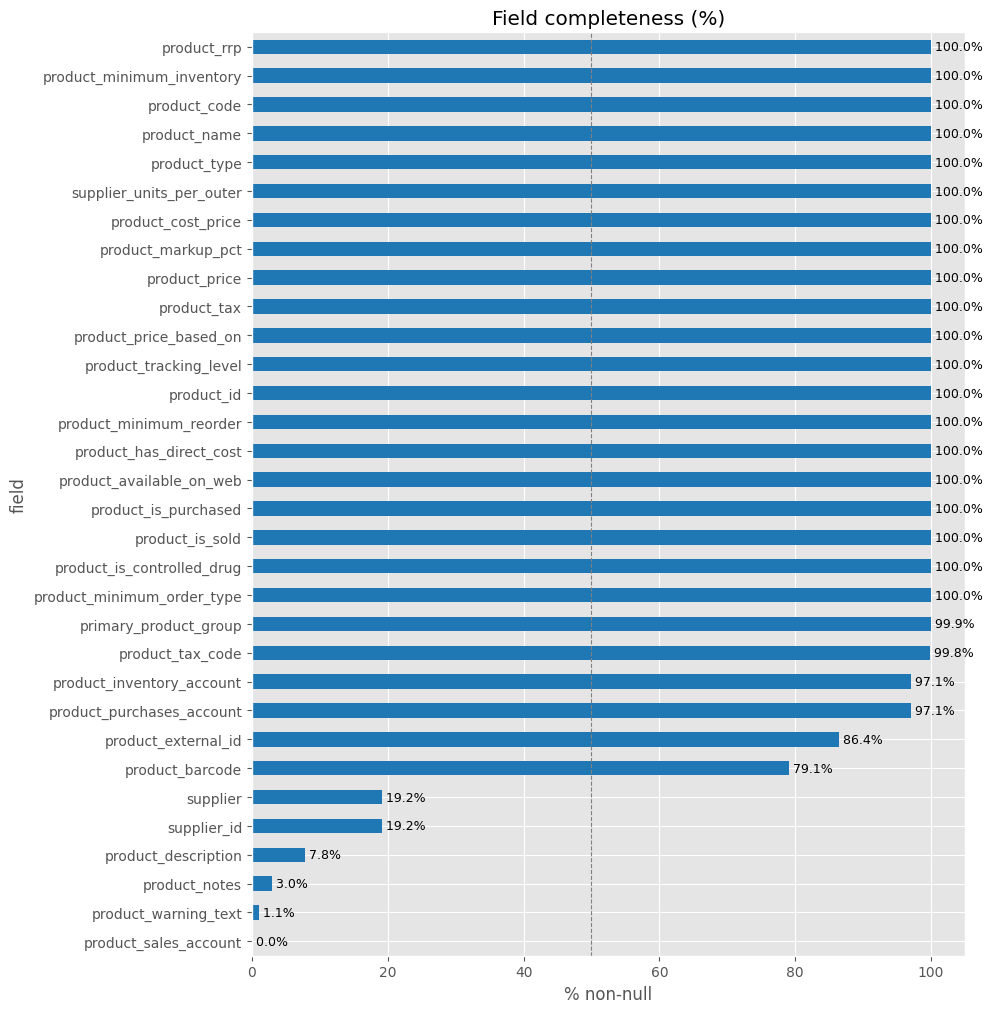

In [3]:
# --- Entity summary table ---
entity_summary = pd.DataFrame([
    {'entity': 'total_products',            'count': len(pms_raw)},
    {'entity': 'active_products',           'count': int(pms_raw['is_active_flag'].sum())},
    {'entity': 'inactive_products',         'count': int((~pms_raw['is_active_flag']).sum())},
    {'entity': 'distinct_product_groups',   'count': pms_raw['primary_product_group'].nunique(dropna=True)},
    {'entity': 'distinct_product_types',    'count': pms_raw['product_type'].nunique(dropna=True)},
    {'entity': 'distinct_suppliers',        'count': pms_raw['supplier'].nunique(dropna=True)},
    {'entity': 'products_with_supplier',    'count': int(pms_raw['has_supplier'].sum())},
    {'entity': 'products_without_supplier', 'count': int((~pms_raw['has_supplier']).sum())},
    {'entity': 'products_taxable',          'count': int((pms_raw['product_tax_code'].str.strip() == '7.45').sum())},
    {'entity': 'products_exempt',           'count': int((pms_raw['product_tax_code'].str.strip() == 'E').sum())},
])
show_metric_table(entity_summary, 'Catalog overview')

# --- Field completeness ---
completeness_fields = [
    'product_id', 'product_external_id', 'product_code', 'product_name',
    'product_description', 'product_barcode', 'primary_product_group',
    'product_type', 'supplier_id', 'supplier', 'supplier_units_per_outer',
    'product_cost_price', 'product_markup_pct', 'product_price', 'product_tax',
    'product_rrp', 'product_price_based_on', 'product_tracking_level',
    'product_minimum_inventory', 'product_minimum_reorder',
    'product_minimum_order_type', 'product_has_direct_cost',
    'product_available_on_web', 'product_is_purchased', 'product_is_sold',
    'product_is_controlled_drug', 'product_tax_code',
    'product_purchases_account', 'product_sales_account',
    'product_inventory_account', 'product_warning_text', 'product_notes',
]
completeness = pd.DataFrame({
    'field': completeness_fields,
    'pct_non_null': [pms_raw[f].notna().mean() * 100 for f in completeness_fields],
}).sort_values('pct_non_null')

show_metric_table(completeness, 'Field completeness (%)')

fig, ax = plt.subplots(figsize=(10, max(6, len(completeness) * 0.32)))
completeness.plot(kind='barh', x='field', y='pct_non_null', ax=ax,
                  color='#1f77b4', legend=False)
ax.set_title('Field completeness (%)')
ax.set_xlabel('% non-null')
ax.axvline(x=50, color='grey', linestyle='--', linewidth=0.8)
annotate_barh(ax, fmt='{:.1f}%')
plt.tight_layout()
plt.show()

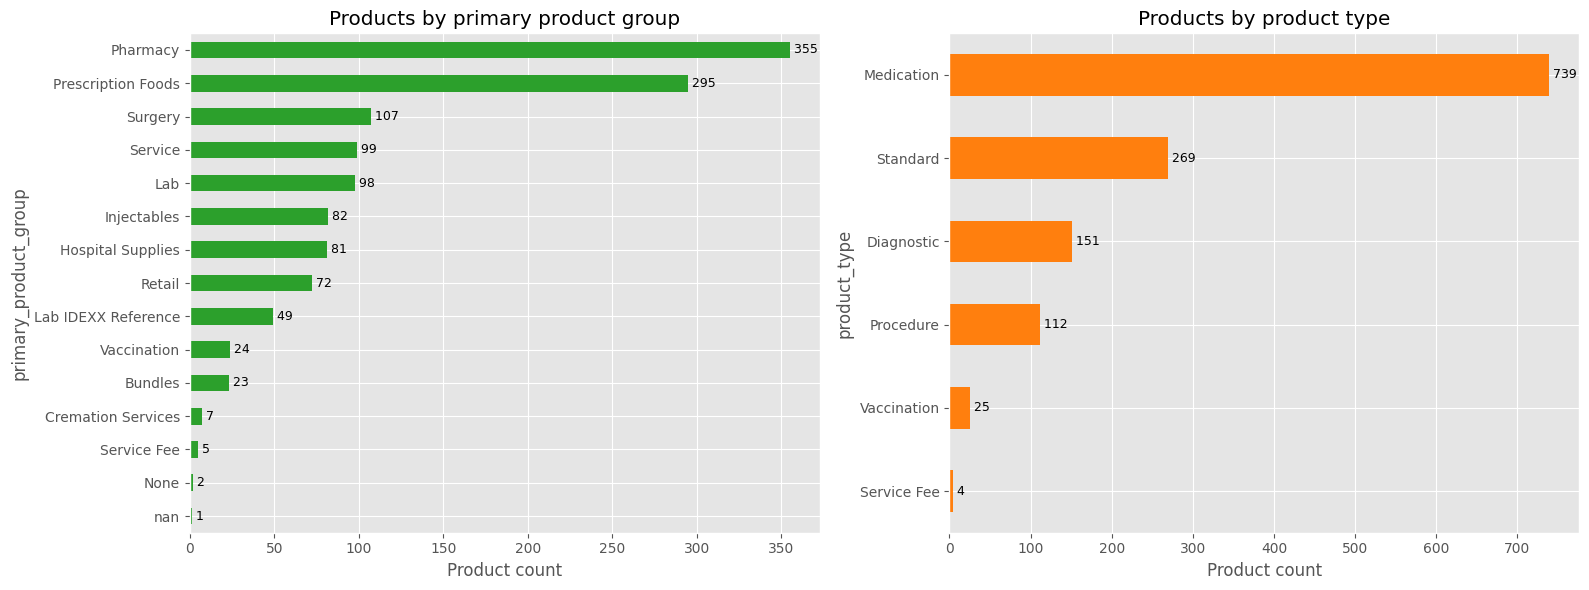

### Product group x product type cross-tab

product_type,Diagnostic,Medication,Procedure,Service Fee,Standard,Vaccination,All
primary_product_group,,,,,,,
Bundles,0,1,3,0,19,0,23
Cremation Services,0,0,2,0,5,0,7
Hospital Supplies,0,3,0,0,78,0,81
Injectables,0,80,0,0,2,0,82
Lab,97,0,0,0,0,1,98
Lab IDEXX Reference,49,0,0,0,0,0,49
None,0,0,0,0,2,0,2
Pharmacy,0,353,0,0,2,0,355
Prescription Foods,0,294,0,0,1,0,295


### Active vs inactive by product group

is_active_flag,active,All
primary_product_group,,
Bundles,23,23
Cremation Services,7,7
Hospital Supplies,81,81
Injectables,82,82
Lab,98,98
Lab IDEXX Reference,49,49
None,2,2
Pharmacy,355,355
Prescription Foods,295,295


In [4]:
# --- Product group and type distribution ---
group_counts = (
    pms_raw['primary_product_group']
    .value_counts(dropna=False)
    .rename_axis('primary_product_group')
    .reset_index(name='products')
    .sort_values('products')
)
type_counts = (
    pms_raw['product_type']
    .value_counts(dropna=False)
    .rename_axis('product_type')
    .reset_index(name='products')
    .sort_values('products')
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
group_counts.plot(kind='barh', x='primary_product_group', y='products',
                  ax=axes[0], color='#2ca02c', legend=False)
axes[0].set_title('Products by primary product group')
axes[0].set_xlabel('Product count')
annotate_barh(axes[0])

type_counts.plot(kind='barh', x='product_type', y='products',
                 ax=axes[1], color='#ff7f0e', legend=False)
axes[1].set_title('Products by product type')
axes[1].set_xlabel('Product count')
annotate_barh(axes[1])

plt.tight_layout()
plt.show()

# Cross-tab: group x type
crosstab = pd.crosstab(
    pms_raw['primary_product_group'],
    pms_raw['product_type'],
    margins=True,
)
show_metric_table(crosstab, 'Product group x product type cross-tab')

# Active vs inactive by group
active_split = pd.crosstab(
    pms_raw['primary_product_group'],
    pms_raw['is_active_flag'],
    margins=True,
).rename(columns={True: 'active', False: 'inactive'})
show_metric_table(active_split, 'Active vs inactive by product group')

### Supplier coverage

,metric,value
0,products_with_supplier,249.00
1,products_without_supplier,"1,051.00"
2,supplier_coverage_pct,19.20
3,distinct_suppliers,1.00


### Supplier product counts

,supplier,products
0,Henry Schein,249


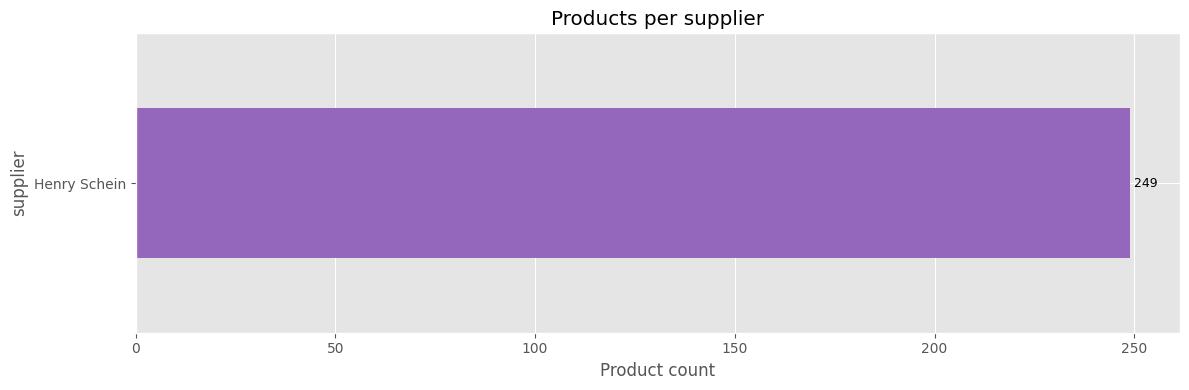

### Supplier x product group cross-tab

primary_product_group,Hospital Supplies,Injectables,Lab,Pharmacy,Prescription Foods,Retail,Service,Surgery,Vaccination,All
supplier,,,,,,,,,,
Henry Schein,1,23,16,114,60,30,1,1,3,249
All,1,23,16,114,60,30,1,1,3,249


In [5]:
# --- Supplier coverage summary ---
supplier_coverage = pd.DataFrame([
    {'metric': 'products_with_supplier',    'value': int(pms_raw['has_supplier'].sum())},
    {'metric': 'products_without_supplier', 'value': int((~pms_raw['has_supplier']).sum())},
    {'metric': 'supplier_coverage_pct',     'value': round(pms_raw['has_supplier'].mean() * 100, 1)},
    {'metric': 'distinct_suppliers',        'value': pms_raw['supplier'].nunique(dropna=True)},
])
show_metric_table(supplier_coverage, 'Supplier coverage')

# --- Top suppliers by product count ---
top_suppliers = (
    pms_raw.dropna(subset=['supplier'])
    .groupby('supplier')
    .size()
    .sort_values()
    .rename_axis('supplier')
    .reset_index(name='products')
)
show_metric_table(
    top_suppliers.sort_values('products', ascending=False),
    'Supplier product counts'
)

fig, ax = plt.subplots(figsize=(12, max(4, len(top_suppliers) * 0.38)))
top_suppliers.plot(kind='barh', x='supplier', y='products',
                   ax=ax, color='#9467bd', legend=False)
ax.set_title('Products per supplier')
ax.set_xlabel('Product count')
annotate_barh(ax)
plt.tight_layout()
plt.show()

# --- Supplier x product group cross-tab ---
sup_products = pms_raw.dropna(subset=['supplier'])
supplier_group_ct = pd.crosstab(
    sup_products['supplier'],
    sup_products['primary_product_group'],
    margins=True,
)
show_metric_table(supplier_group_ct, 'Supplier x product group cross-tab')

### Markup summary

,metric,value
0,products_with_markup_pct,"1,300.00"
1,negative_markup_products,9.00
2,zero_markup_products,316.00
3,median_markup_pct,50.00
4,mean_markup_pct,126.30


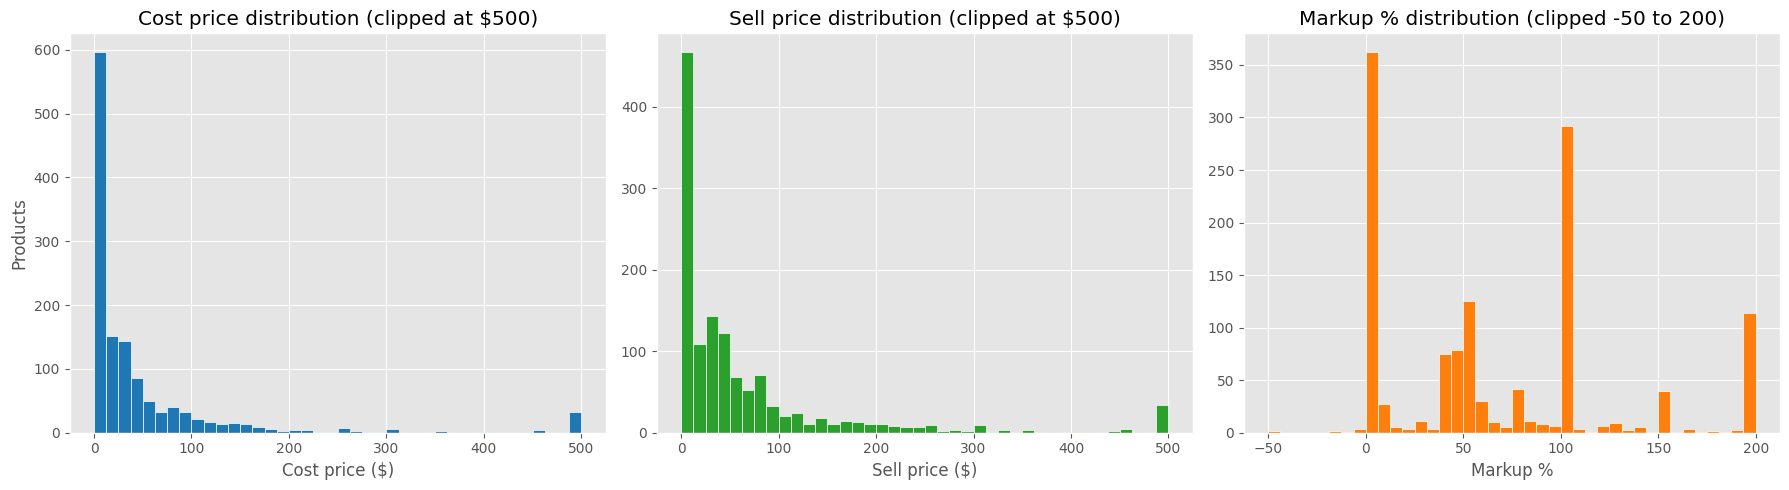

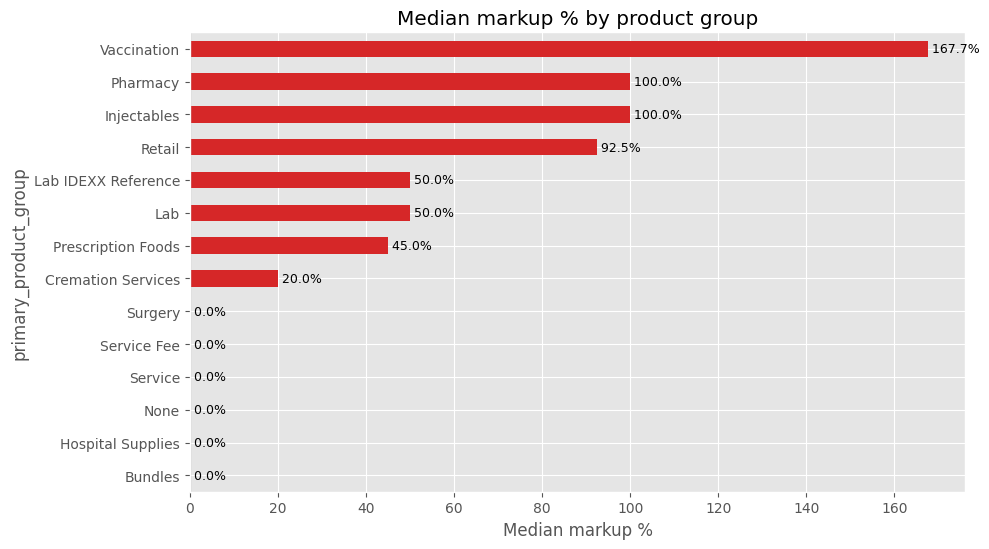

### Sample negative-markup products

,product_code,product_name,primary_product_group,product_type,product_markup_pct_num
10,MAH_RECHK,Rescue Recheck,Service,Standard,-16.67
89,MAH_PRO123,Proheart 12 Injection,Injectables,Medication,-100.00
158,MAH_LIB30A,Librela 30 mg additional vial,Injectables,Medication,-18.18
431,MAH_1546,Hill's Feline ProPak Healthy Adv EMPLOYE,Prescription Foods,Medication,-0.01
491,MAH_PRO63,Proheart 6 Injection,Injectables,Medication,-100.00
569,MAH_LIB20A,Librela 20 mg additional vial,Injectables,Medication,-8.16
575,MAH_603935,Hill's feline C/D Stress 8.5 lb,Prescription Foods,Medication,-0.01
685,MAH_LIB15A,Librela 15 mg additional vial,Injectables,Medication,-4.76
988,MAH_10045,Hill's Feline Metabolic + Urinary 6.35 l,Prescription Foods,Medication,-0.01


In [6]:
# --- Pricing distributions and markup ---
neg_markup = pms_raw[pms_raw['product_markup_pct_num'] < 0]
markup_summary = pd.DataFrame([
    {'metric': 'products_with_markup_pct',  'value': int(pms_raw['product_markup_pct_num'].notna().sum())},
    {'metric': 'negative_markup_products',  'value': len(neg_markup)},
    {'metric': 'zero_markup_products',      'value': int((pms_raw['product_markup_pct_num'] == 0).sum())},
    {'metric': 'median_markup_pct',         'value': round(pms_raw['product_markup_pct_num'].median(), 2)},
    {'metric': 'mean_markup_pct',           'value': round(pms_raw['product_markup_pct_num'].mean(), 2)},
])
show_metric_table(markup_summary, 'Markup summary')

# Histograms: cost, price, markup
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pms_raw['product_cost_price_num'].dropna().clip(upper=500).hist(
    bins=40, ax=axes[0], color='#1f77b4', edgecolor='white')
axes[0].set_title('Cost price distribution (clipped at $500)')
axes[0].set_xlabel('Cost price ($)')
axes[0].set_ylabel('Products')

pms_raw['product_price_num'].dropna().clip(upper=500).hist(
    bins=40, ax=axes[1], color='#2ca02c', edgecolor='white')
axes[1].set_title('Sell price distribution (clipped at $500)')
axes[1].set_xlabel('Sell price ($)')

pms_raw['product_markup_pct_num'].dropna().clip(lower=-50, upper=200).hist(
    bins=40, ax=axes[2], color='#ff7f0e', edgecolor='white')
axes[2].set_title('Markup % distribution (clipped -50 to 200)')
axes[2].set_xlabel('Markup %')

plt.tight_layout()
plt.show()

# Median markup by product group
markup_by_group = (
    pms_raw.dropna(subset=['product_markup_pct_num', 'primary_product_group'])
    .groupby('primary_product_group')['product_markup_pct_num']
    .median()
    .sort_values()
    .rename_axis('primary_product_group')
    .reset_index(name='median_markup_pct')
)
fig, ax = plt.subplots(figsize=(10, max(4, len(markup_by_group) * 0.4)))
markup_by_group.plot(kind='barh', x='primary_product_group', y='median_markup_pct',
                     ax=ax, color='#d62728', legend=False)
ax.set_title('Median markup % by product group')
ax.set_xlabel('Median markup %')
ax.axvline(x=0, color='black', linewidth=0.8)
annotate_barh(ax, fmt='{:,.1f}%')
plt.tight_layout()
plt.show()

# Negative-markup product sample
show_metric_table(
    neg_markup[['product_code', 'product_name', 'primary_product_group',
                'product_type', 'product_markup_pct_num']].head(15),
    'Sample negative-markup products'
)

### Tax code split by product group

product_tax_code,7.45,E,All
primary_product_group,,,
Bundles,0,22,22
Cremation Services,0,7,7
Hospital Supplies,1,79,80
Injectables,4,77,81
Lab,1,97,98
Lab IDEXX Reference,0,49,49
None,0,2,2
Pharmacy,338,17,355
Prescription Foods,289,6,295


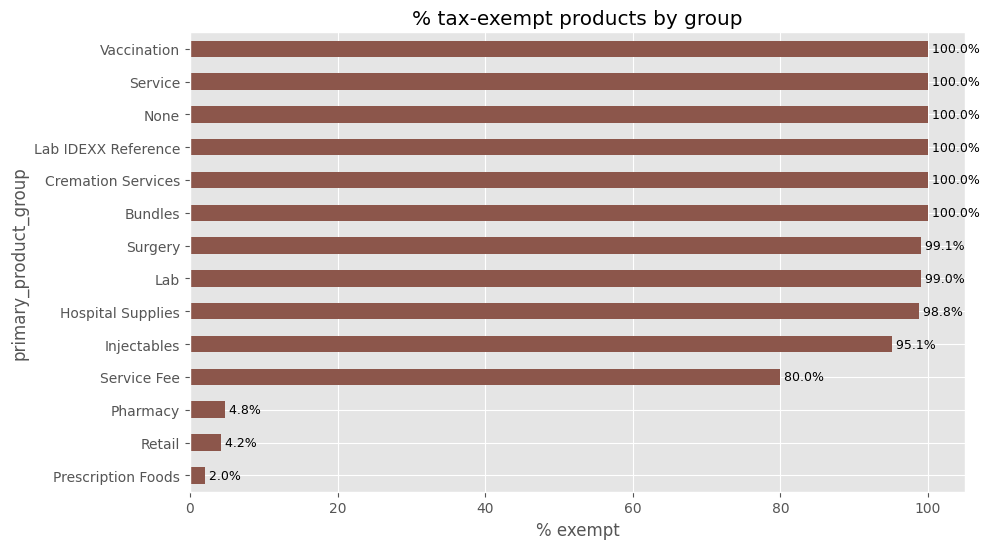

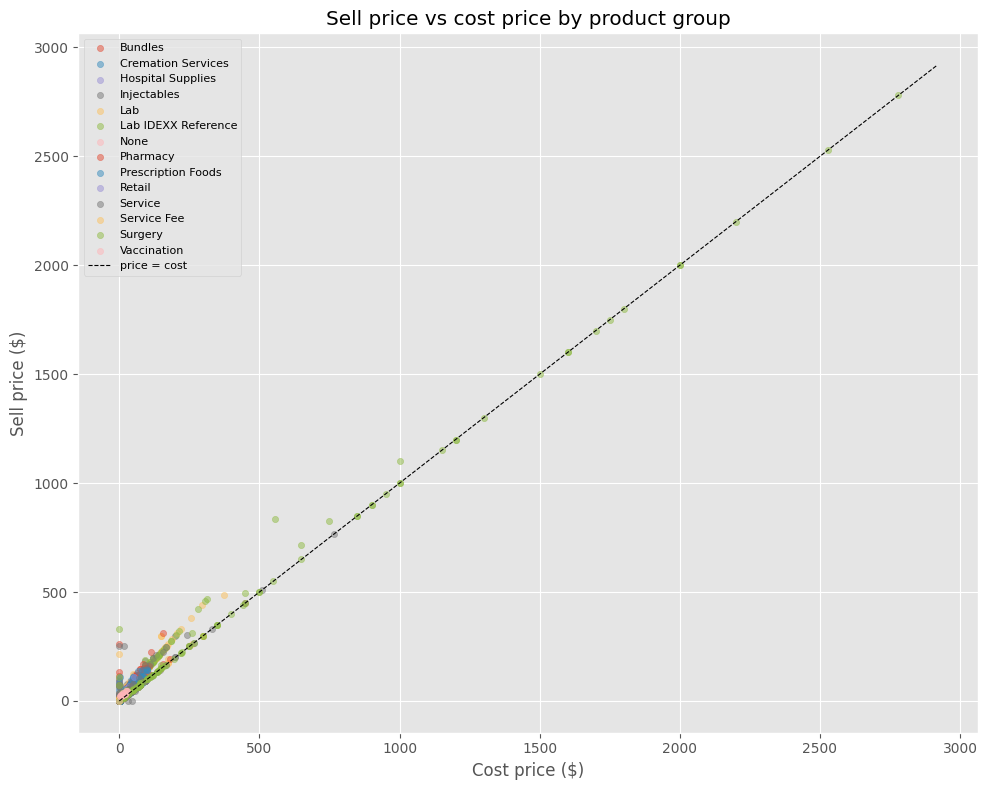

### RRP vs sell price summary (non-zero RRP only)

,metric,value
0,products_with_nonzero_rrp,0
1,price_below_rrp,0
2,price_above_rrp,0
3,price_equals_rrp,0


In [7]:
# --- Tax split by product group ---
tax_split = pd.crosstab(
    pms_raw['primary_product_group'],
    pms_raw['product_tax_code'].str.strip(),
    margins=True,
)
show_metric_table(tax_split, 'Tax code split by product group')

# Tax-exempt proportion by group
if 'E' in tax_split.columns and 'All' in tax_split.index:
    tax_pct = (
        tax_split.drop(index='All')
        .assign(pct_exempt=lambda d: d.get('E', 0) / d['All'] * 100)
        [['pct_exempt']]
        .sort_values('pct_exempt')
        .rename_axis('primary_product_group')
        .reset_index()
    )
    fig, ax = plt.subplots(figsize=(10, max(4, len(tax_pct) * 0.4)))
    tax_pct.plot(kind='barh', x='primary_product_group', y='pct_exempt',
                 ax=ax, color='#8c564b', legend=False)
    ax.set_title('% tax-exempt products by group')
    ax.set_xlabel('% exempt')
    annotate_barh(ax, fmt='{:.1f}%')
    plt.tight_layout()
    plt.show()

# --- Price vs cost scatter by group ---
scatter_df = pms_raw.dropna(subset=['product_cost_price_num', 'product_price_num'])
groups = sorted(scatter_df['primary_product_group'].dropna().unique())
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
color_map = {g: colors[i % len(colors)] for i, g in enumerate(groups)}

fig, ax = plt.subplots(figsize=(10, 8))
for group in groups:
    gdf = scatter_df[scatter_df['primary_product_group'] == group]
    ax.scatter(gdf['product_cost_price_num'], gdf['product_price_num'],
               alpha=0.5, label=group, color=color_map[group], s=20)

max_val = max(scatter_df['product_cost_price_num'].max(),
              scatter_df['product_price_num'].max()) * 1.05
ax.plot([0, max_val], [0, max_val], 'k--', linewidth=0.8, label='price = cost')
ax.set_title('Sell price vs cost price by product group')
ax.set_xlabel('Cost price ($)')
ax.set_ylabel('Sell price ($)')
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

# --- RRP vs price summary ---
rrp_nonzero = pms_raw[
    pms_raw['product_rrp_num'].notna() & (pms_raw['product_rrp_num'] != 0)
    & pms_raw['product_price_num'].notna()
].copy()
rrp_nonzero['rrp_vs_price'] = rrp_nonzero['product_rrp_num'] - rrp_nonzero['product_price_num']

rrp_summary = pd.DataFrame([
    {'metric': 'products_with_nonzero_rrp', 'value': len(rrp_nonzero)},
    {'metric': 'price_below_rrp',           'value': int((rrp_nonzero['rrp_vs_price'] > 0).sum())},
    {'metric': 'price_above_rrp',           'value': int((rrp_nonzero['rrp_vs_price'] < 0).sum())},
    {'metric': 'price_equals_rrp',          'value': int((rrp_nonzero['rrp_vs_price'] == 0).sum())},
])
show_metric_table(rrp_summary, 'RRP vs sell price summary (non-zero RRP only)')

### is_purchased x is_sold cross-tab

product_is_sold,NO,YES,All
product_is_purchased,,,
NO,2,351,353
YES,63,884,947
All,65,1235,1300


### Dead catalog entries

,metric,value
0,dead_catalog_entries (not purchased and not sold),2


### Sample dead catalog entries

,product_code,product_name,primary_product_group,product_type,product_is_active
1151,MAH_INV_FORTF,Probiotic Fortiflora Feline Per Packet,Retail,Medication,YES
1295,6003180,May Promo - Allergy Month,None,Standard,YES


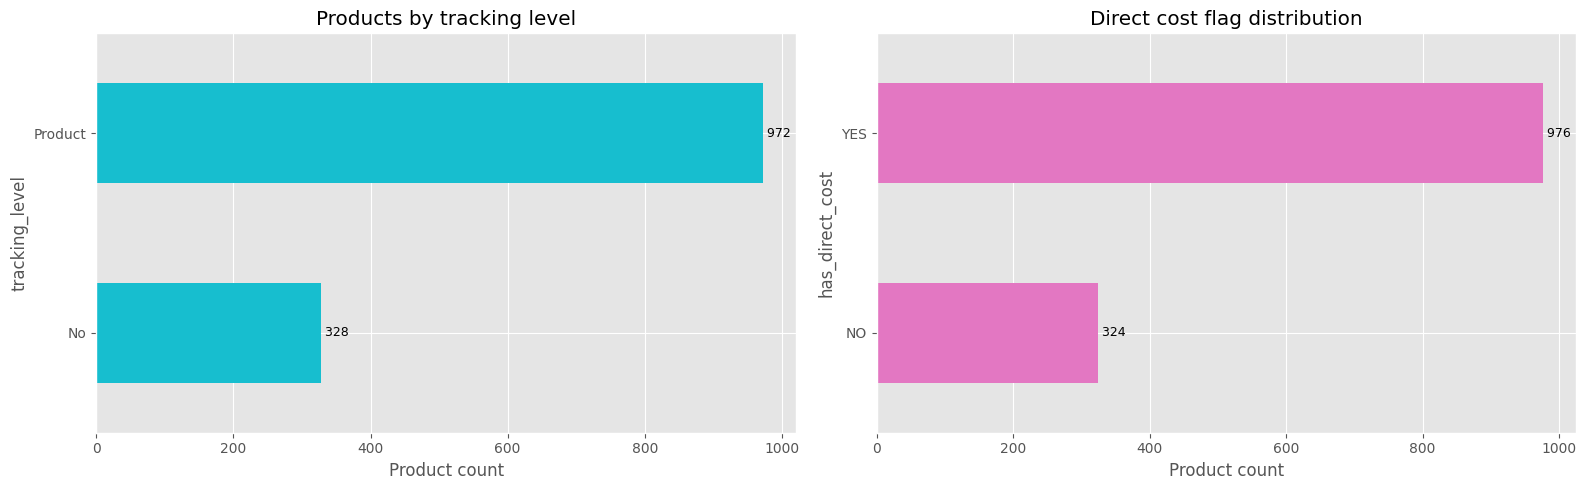

### Available on web distribution

,available_on_web,products
0,NO,1300


In [8]:
# --- is_purchased x is_sold cross-tab ---
purchase_sold_ct = pd.crosstab(
    pms_raw['product_is_purchased'].fillna('(null)'),
    pms_raw['product_is_sold'].fillna('(null)'),
    margins=True,
)
show_metric_table(purchase_sold_ct, 'is_purchased x is_sold cross-tab')

# Dead-catalog entries: not purchased AND not sold
dead = pms_raw[
    (pms_raw['product_is_purchased'].str.upper() != 'YES')
    & (pms_raw['product_is_sold'].str.upper() != 'YES')
]
show_metric_table(
    pd.DataFrame([{'metric': 'dead_catalog_entries (not purchased and not sold)',
                   'value': len(dead)}]),
    'Dead catalog entries'
)
if len(dead) > 0:
    show_metric_table(
        dead[['product_code', 'product_name', 'primary_product_group',
              'product_type', 'product_is_active']].head(15),
        'Sample dead catalog entries'
    )

# --- Tracking level breakdown ---
tracking_counts = (
    pms_raw['product_tracking_level']
    .value_counts(dropna=False)
    .rename_axis('tracking_level')
    .reset_index(name='products')
    .sort_values('products')
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
tracking_counts.plot(kind='barh', x='tracking_level', y='products',
                     ax=axes[0], color='#17becf', legend=False)
axes[0].set_title('Products by tracking level')
axes[0].set_xlabel('Product count')
annotate_barh(axes[0])

# --- has_direct_cost distribution ---
direct_cost_counts = (
    pms_raw['product_has_direct_cost']
    .value_counts(dropna=False)
    .rename_axis('has_direct_cost')
    .reset_index(name='products')
    .sort_values('products')
)
direct_cost_counts.plot(kind='barh', x='has_direct_cost', y='products',
                        ax=axes[1], color='#e377c2', legend=False)
axes[1].set_title('Direct cost flag distribution')
axes[1].set_xlabel('Product count')
annotate_barh(axes[1])

plt.tight_layout()
plt.show()

# --- available_on_web distribution ---
web_available = (
    pms_raw['product_available_on_web']
    .value_counts(dropna=False)
    .rename_axis('available_on_web')
    .reset_index(name='products')
)
show_metric_table(web_available, 'Available on web distribution')

In [9]:
# --- Catalog quality ---
barcode_coverage = pms_raw['product_barcode'].notna().mean() * 100
barcode_matches_suffix = (
    pms_raw.dropna(subset=['product_barcode', 'product_code'])
    .apply(lambda r: str(r['product_code']).endswith(str(r['product_barcode'])), axis=1)
    .sum()
)
quality_summary = pd.DataFrame([
    {'metric': 'products_with_barcode',           'value': int(pms_raw['product_barcode'].notna().sum())},
    {'metric': 'barcode_coverage_pct',            'value': round(barcode_coverage, 1)},
    {'metric': 'barcodes_matching_code_suffix',   'value': int(barcode_matches_suffix)},
    {'metric': 'products_with_description',       'value': int(pms_raw['product_description'].notna().sum())},
    {'metric': 'products_with_warning_text',      'value': int(pms_raw['product_warning_text'].notna().sum())},
    {'metric': 'products_with_notes',             'value': int(pms_raw['product_notes'].notna().sum())},
])
show_metric_table(quality_summary, 'Catalog quality metrics')

# --- Duplicate product_name detection ---
dup_names = (
    pms_raw.groupby('product_name').size()
    .reset_index(name='occurrences')
    .query('occurrences > 1')
    .sort_values('occurrences', ascending=False)
)
show_metric_table(
    dup_names.head(20),
    f'Duplicate product_name entries ({len(dup_names)} names duplicated)'
)

# --- Duplicate product_code detection ---
dup_codes = (
    pms_raw.groupby('product_code').size()
    .reset_index(name='occurrences')
    .query('occurrences > 1')
    .sort_values('occurrences', ascending=False)
)
show_metric_table(
    dup_codes.head(20),
    f'Duplicate product_code entries ({len(dup_codes)} codes duplicated)'
)

# --- Most common warning_text values ---
warning_vals = pms_raw['product_warning_text'].value_counts(dropna=True)
if len(warning_vals) > 0:
    show_metric_table(
        warning_vals.head(10).rename_axis('warning_text').reset_index(name='count'),
        'Most common warning_text values'
    )

# --- Accounting field coverage ---
account_fields = [
    'product_purchases_account', 'product_sales_account',
    'product_inventory_account',
]
account_completeness = pd.DataFrame({
    'field': account_fields,
    'non_null_count': [int(pms_raw[f].notna().sum()) for f in account_fields],
    'pct_non_null': [round(pms_raw[f].notna().mean() * 100, 1) for f in account_fields],
})
show_metric_table(account_completeness, 'Accounting field coverage')

### Catalog quality metrics

,metric,value
0,products_with_barcode,"1,028.00"
1,barcode_coverage_pct,79.10
2,barcodes_matching_code_suffix,"1,022.00"
3,products_with_description,101.00
4,products_with_warning_text,14.00
5,products_with_notes,39.00


### Duplicate product_name entries (2 names duplicated)

,product_name,occurrences
675,Ionized Calcium,2
956,Proviable DC Caps per capsule,2


### Duplicate product_code entries (0 codes duplicated)

,product_code,occurrences


### Most common warning_text values

,warning_text,count
0,Give with food.,6
1,KEEP REFRIGERATED,1
2,May cause sedation.,1
3,Give with food.,1
4,May cause gastrointestinal upset. Give with food.,1
5,Keep Refrigerated,1
6,GIVE WITH FOOD,1
7,Wear gloves when applying.,1
8,WEAR NON-PERMEABLE GLOVES WHEN APPLYING,1


### Accounting field coverage

,field,non_null_count,pct_non_null
0,product_purchases_account,1262,97.10
1,product_sales_account,0,0.00
2,product_inventory_account,1262,97.10


### Average pricing metrics by supplier

,supplier,product_count,avg_cost_price,avg_sell_price,avg_markup_pct,median_markup_pct
0,Henry Schein,249,23.03,38.41,95.58,85.00


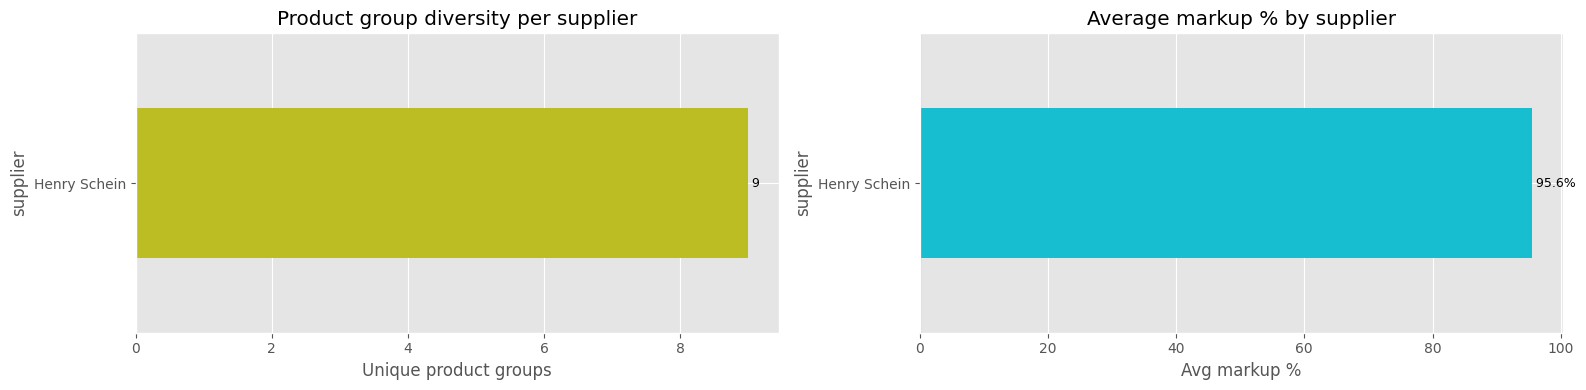

### Pricing field completeness by supplier (%)

,supplier,product_count,product_cost_price_num_pct,product_price_num_pct,product_markup_pct_num_pct,all_pricing_complete_pct
0,Henry Schein,249,100.00,100.00,100.00,100.00


In [10]:
# --- Supplier-Product deep dive ---
sup_df = pms_raw.dropna(subset=['supplier'])

# Product group diversity per supplier
diversity = (
    sup_df.groupby('supplier')['primary_product_group']
    .nunique()
    .sort_values()
    .rename_axis('supplier')
    .reset_index(name='unique_product_groups')
)

# Average pricing by supplier
pricing_by_supplier = (
    sup_df.dropna(subset=['product_price_num'])
    .groupby('supplier')
    .agg(
        product_count=('product_id', 'size'),
        avg_cost_price=('product_cost_price_num', 'mean'),
        avg_sell_price=('product_price_num', 'mean'),
        avg_markup_pct=('product_markup_pct_num', 'mean'),
        median_markup_pct=('product_markup_pct_num', 'median'),
    )
    .round(2)
    .sort_values('product_count', ascending=False)
    .reset_index()
)
show_metric_table(pricing_by_supplier, 'Average pricing metrics by supplier')

fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(pricing_by_supplier) * 0.5)))
diversity.plot(kind='barh', x='supplier', y='unique_product_groups',
               ax=axes[0], color='#bcbd22', legend=False)
axes[0].set_title('Product group diversity per supplier')
axes[0].set_xlabel('Unique product groups')
annotate_barh(axes[0])

pricing_by_supplier.sort_values('avg_markup_pct').plot(
    kind='barh', x='supplier', y='avg_markup_pct',
    ax=axes[1], color='#17becf', legend=False
)
axes[1].set_title('Average markup % by supplier')
axes[1].set_xlabel('Avg markup %')
axes[1].axvline(x=0, color='black', linewidth=0.8)
annotate_barh(axes[1], fmt='{:,.1f}%')

plt.tight_layout()
plt.show()

# --- Pricing field completeness by supplier ---
PRICING_NUM_COLS = [
    'product_cost_price_num', 'product_price_num', 'product_markup_pct_num'
]
sup_completeness_rows = []
for supplier, grp in sup_df.groupby('supplier'):
    row = {'supplier': supplier, 'product_count': len(grp)}
    for col in PRICING_NUM_COLS:
        row[f'{col}_pct'] = round(grp[col].notna().mean() * 100, 1)
    row['all_pricing_complete_pct'] = round(
        grp[PRICING_NUM_COLS].notna().all(axis=1).mean() * 100, 1
    )
    sup_completeness_rows.append(row)

sup_completeness = (
    pd.DataFrame(sup_completeness_rows)
    .sort_values('all_pricing_complete_pct', ascending=False)
)
show_metric_table(sup_completeness, 'Pricing field completeness by supplier (%)')

In [11]:
# --- Markup outliers (3 x IQR) ---
markup_vals = pms_raw['product_markup_pct_num'].dropna()
q1, q3 = markup_vals.quantile(0.25), markup_vals.quantile(0.75)
iqr = q3 - q1
lower_fence = q1 - 3 * iqr
upper_fence = q3 + 3 * iqr

outliers = pms_raw[
    (pms_raw['product_markup_pct_num'] < lower_fence)
    | (pms_raw['product_markup_pct_num'] > upper_fence)
].copy()

outlier_summary = pd.DataFrame([
    {'metric': 'markup_q1',              'value': round(q1, 2)},
    {'metric': 'markup_q3',              'value': round(q3, 2)},
    {'metric': 'markup_iqr',             'value': round(iqr, 2)},
    {'metric': 'lower_fence_3xIQR',      'value': round(lower_fence, 2)},
    {'metric': 'upper_fence_3xIQR',      'value': round(upper_fence, 2)},
    {'metric': 'outlier_product_count',  'value': len(outliers)},
])
show_metric_table(outlier_summary, 'Markup % outlier fence (3 x IQR)')

if len(outliers) > 0:
    show_metric_table(
        outliers[['product_code', 'product_name', 'primary_product_group',
                  'product_type', 'product_markup_pct_num', 'product_price_num',
                  'product_cost_price_num']].head(20),
        'Markup outlier products (sample)'
    )

# --- Pricing stats by product type ---
type_pricing = (
    pms_raw.dropna(subset=['product_type', 'product_price_num'])
    .groupby('product_type')
    .agg(
        count=('product_id', 'size'),
        median_price=('product_price_num', 'median'),
        median_cost=('product_cost_price_num', 'median'),
        median_markup_pct=('product_markup_pct_num', 'median'),
    )
    .round(2)
    .reset_index()
)

# Add pct negative markup per type
neg_by_type = (
    pms_raw.dropna(subset=['product_type', 'product_markup_pct_num'])
    .groupby('product_type')['product_markup_pct_num']
    .agg(pct_negative_markup=lambda s: round((s < 0).mean() * 100, 1))
    .reset_index()
)
type_pricing = type_pricing.merge(neg_by_type, on='product_type', how='left')
show_metric_table(type_pricing, 'Pricing statistics by product type')

### Markup % outlier fence (3 x IQR)

,metric,value
0,markup_q1,0.01
1,markup_q3,100.00
2,markup_iqr,99.99
3,lower_fence_3xIQR,-299.97
4,upper_fence_3xIQR,399.98
5,outlier_product_count,52.00


### Markup outlier products (sample)

,product_code,product_name,primary_product_group,product_type,product_markup_pct_num,product_price_num,product_cost_price_num
9,MAH_MELOX75,Meloxicam 7.5mg,Pharmacy,Medication,500.00,0.12,0.02
34,MAH_TMS960,Sulfamethoxazole and Trimethoprim 960mg,Pharmacy,Medication,500.00,0.24,0.04
106,MAH_DERM2,Fungal Culture,Lab,Diagnostic,"1,419.82",34.50,2.27
110,MAH_FAMO1,Famotidine 20mg,Pharmacy,Medication,400.00,0.30,0.06
208,MAH_471418,RC Feline Satiety 18.7,Prescription Foods,Medication,"7,416.11",111.99,1.49
212,MAH_DIPH,Diphenhydramine Inj per mL,Injectables,Medication,"1,000.00",15.40,1.40
252,MAH_AMLOD,Amlodipine 2.5mg Tablet,Pharmacy,Medication,580.00,0.34,0.05
343,MAH_GLU,Glucose Test (glucometer),Lab,Diagnostic,"1,600.00",17.00,1.00
346,MAH_IVB,Fluids- Lactated Ringers 1 L,Hospital Supplies,Medication,492.89,30.00,5.06
356,MAH_STT,Schirmer Tear Test,Lab,Diagnostic,"2,400.00",37.75,1.51


### Pricing statistics by product type

,product_type,count,median_price,median_cost,median_markup_pct,pct_negative_markup
0,Diagnostic,151,157.50,98.00,50.00,0.00
1,Medication,739,21.18,8.98,100.00,1.10
2,Procedure,112,136.00,120.00,0.00,0.00
3,Service Fee,4,9.50,6.00,0.00,0.00
4,Standard,269,16.00,7.36,0.00,0.40
5,Vaccination,25,29.50,10.50,167.70,0.00


## Modeling takeaways for the ingestion pipeline

- Treat `heydonto_mdm.pms_ezyvet_report` as a raw product catalog landing table.
  The ingestion pipeline should cast the eight numeric TEXT columns to proper
  NUMERIC types during transformation; do not attempt to evaluate markup rules
  in the landing layer.
- `product_division` is a constant (`'1'`) in this single-clinic extract; omit it
  from dimensional models or hard-code it as a filter.
- `product_sales_account` and `product_minimum_inventory` are dead columns in
  this extract; exclude them from the canonical product dimension to avoid
  confusion downstream.
- Supplier assignment is sparse. Build the supplier dimension to tolerate NULL
  `supplier_id`; do not enforce a NOT NULL FK constraint from the product table.
- Negative-markup products are real and valid (typically services sold below list
  cost). Downstream margin calculations must handle negative margin without
  flagging these as errors.
- Use `product_id` as the surrogate key; `product_code` is the natural/business
  key for POS joins but may have duplicates — validate before promoting it to a
  UNIQUE constraint.
- `product_tax_code` is binary (`'7.45'` vs `'E'`); model it as a boolean
  `is_taxable` flag in the product dimension.
- The `is_purchased x is_sold` cross-tab reveals dead catalog entries (not
  purchased and not sold). Tag these with an `is_dead_entry` flag rather than
  purging them, to preserve referential integrity with historical PMS transaction
  data.
- `primary_product_group` is the primary segmentation axis for downstream pricing
  and inventory analytics; ensure it has a proper dimension table with
  `primary_product_group_id` as the key.